# Snabb EDA: CFPB Consumer Complaint Narratives

Jämförelse inför gruppens val av dataset.

**Källa:** Consumer Financial Protection Bureau (CFPB), USA  
**Arkiv:** https://www.consumerfinance.gov/foia-requests/foia-electronic-reading-room/cfpb-consumer-complaint-database-narratives-archive/  
**Fältbeskrivning:** https://cfpb.github.io/api/ccdb/fields.html  

**Viktigt om källan:** I augusti 2026 slutade CFPB publicera klagomålstexterna i den löpande databasen. Den vanliga nedladdningen (`complaints.csv.zip`) innehåller därför bara kategorier, ingen fritext. Texterna från december 2011 till augusti 2026 finns kvar i ett arkiv i CFPB:s FOIA-läsrum, uppdelat i zip-filer per tidsperiod. Arkivsidan anger inga uttryckliga användarvillkor.

Den här EDA:n använder exporten för mars 2026.

In [1]:
from pathlib import Path
import urllib.request
import zipfile
 
import pandas as pd
import matplotlib.pyplot as plt
 
URL = "https://files.consumerfinance.gov/f/documents/CCDB_Export_16_March_2026.zip"
RAW_DIR = Path("../data/raw")
ZIP_PATH = RAW_DIR / "cfpb_narratives_2026_03.zip"
 
RAW_DIR.mkdir(parents=True, exist_ok=True)
if not ZIP_PATH.exists():
    print("Laddar ner ...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
print(f"Filstorlek: {ZIP_PATH.stat().st_size / 1e6:.0f} MB")

Filstorlek: 22 MB


## Innehåll i zip-filen och kolumner

In [2]:
with zipfile.ZipFile(ZIP_PATH) as z:
    for info in z.infolist():
        print(f"{info.filename}  ({info.file_size / 1e6:.0f} MB uppackad)")
    csv_files = [n for n in z.namelist() if n.lower().endswith(".csv")]
 
print("\nCSV-filer:", csv_files)

CCDB_Export_16_March_2026.csv  (220 MB uppackad)

CSV-filer: ['CCDB_Export_16_March_2026.csv']


In [3]:
with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open(csv_files[0]) as f:
        cols = pd.read_csv(f, nrows=0).columns.tolist()
 
for c in cols:
    print(repr(c))
 
# Hitta textkolumnen automatiskt, ifall namnet skiljer sig
TEXT_COL = next(c for c in cols if "narrative" in c.lower())
print("\nTextkolumn:", TEXT_COL)

'Date received'
'Product'
'Sub-product'
'Issue'
'Sub-issue'
'Consumer complaint narrative'
'Company public response'
'Company'
'State'
'ZIP code'
'Tags'
'Submitted via'
'Date sent to company'
'Company response to consumer'
'Timely response?'
'Complaint ID'

Textkolumn: Consumer complaint narrative


## Inläsning

In [4]:
parts = []
with zipfile.ZipFile(ZIP_PATH) as z:
    for name in csv_files:
        with z.open(name) as f:
            parts.append(pd.read_csv(f, low_memory=False))
df = pd.concat(parts, ignore_index=True)
 
print(df.shape)
df.info()

(614945, 16)
<class 'pandas.DataFrame'>
RangeIndex: 614945 entries, 0 to 614944
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Date received                 614945 non-null  str  
 1   Product                       614945 non-null  str  
 2   Sub-product                   614945 non-null  str  
 3   Issue                         614945 non-null  str  
 4   Sub-issue                     607828 non-null  str  
 5   Consumer complaint narrative  21640 non-null   str  
 6   Company public response       382758 non-null  str  
 7   Company                       614945 non-null  str  
 8   State                         614176 non-null  str  
 9   ZIP code                      614945 non-null  str  
 10  Tags                          12667 non-null   str  
 11  Submitted via                 614945 non-null  str  
 12  Date sent to company          614945 non-null  str  
 13  Company resp

In [5]:
df["Date received"] = pd.to_datetime(df["Date received"])
print("Tidsperiod:", df["Date received"].min().date(), "-", df["Date received"].max().date())
print("Klagomål med fritext:", df[TEXT_COL].notna().sum(), "av", len(df))
 
# Arbeta vidare bara med klagomål som har text
df = df[df[TEXT_COL].notna()].copy()

Tidsperiod: 2026-03-01 - 2026-03-31
Klagomål med fritext: 21640 av 614945


## Kategorier (möjliga etiketter)

In [6]:
print("Antal produkter:", df["Product"].nunique())
print(df["Product"].value_counts())

Antal produkter: 11
Product
Debt collection                                            8263
Checking or savings account                                3450
Credit card                                                3362
Money transfer, virtual currency, or money service         1664
Mortgage                                                   1257
Vehicle loan or lease                                      1028
Credit reporting or other personal consumer reports         816
Student loan                                                704
Payday loan, title loan, personal loan, or advance loan     673
Prepaid card                                                216
Debt or credit management                                   207
Name: count, dtype: int64


In [7]:
print("Antal ärendetyper (Issue):", df["Issue"].nunique())
print(df["Issue"].value_counts().head(15))

Antal ärendetyper (Issue): 82
Issue
Attempts to collect debt not owed                               4830
Managing an account                                             2004
Written notification about debt                                 1203
Problem with a purchase shown on your statement                 1168
False statements or representation                              1029
Incorrect information on your report                             832
Trouble during payment process                                   672
Took or threatened to take negative or legal action              653
Fraud or scam                                                    535
Problem with a lender or other company charging your account     516
Other features, terms, or problems                               437
Fees or interest                                                 432
Closing an account                                               429
Dealing with your lender or servicer                             38

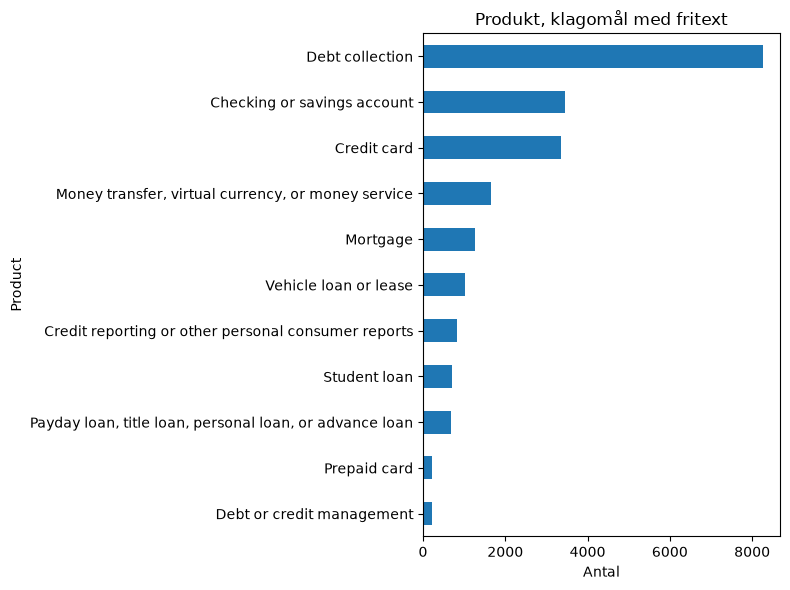

In [8]:
df["Product"].value_counts().sort_values().plot(
    kind="barh", figsize=(8, 6), title="Produkt, klagomål med fritext")
plt.xlabel("Antal")
plt.tight_layout()
plt.show()

## Textlängd

count    21640.0
mean       213.0
std        215.0
min          7.0
25%         90.0
50%        158.0
75%        270.0
max       4994.0
Name: n_words, dtype: float64


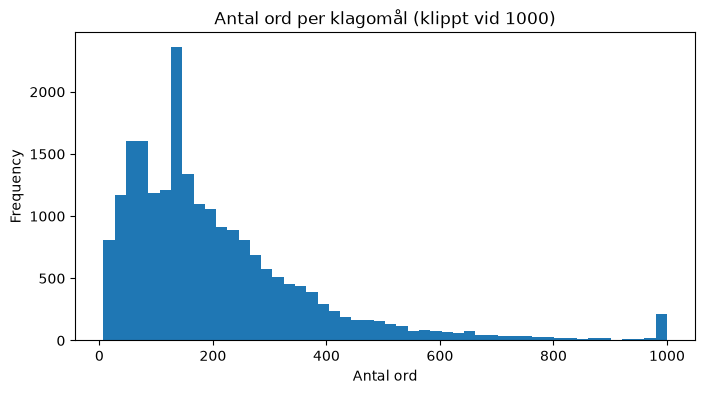

In [9]:
df["n_words"] = df[TEXT_COL].str.split().str.len()
print(df["n_words"].describe().round(0))
 
df["n_words"].clip(upper=1000).plot(
    kind="hist", bins=50, figsize=(8, 4), title="Antal ord per klagomål (klippt vid 1000)")
plt.xlabel("Antal ord")
plt.show()

In [10]:
print("Medianlängd (ord) per produkt:")
print(df.groupby("Product")["n_words"].median().sort_values())

Medianlängd (ord) per produkt:
Product
Debt or credit management                                  103.0
Credit reporting or other personal consumer reports        112.5
Debt collection                                            131.0
Prepaid card                                               147.5
Money transfer, virtual currency, or money service         183.0
Payday loan, title loan, personal loan, or advance loan    184.0
Checking or savings account                                190.0
Student loan                                               198.5
Vehicle loan or lease                                      202.0
Credit card                                                211.0
Mortgage                                                   237.0
Name: n_words, dtype: float64


## Datakvalitet

In [11]:
text = df[TEXT_COL]
print("Dubblerade Complaint ID:", df["Complaint ID"].duplicated().sum())
print("Dubblerade texter:", text.duplicated().sum())
print("Texter kortare än 10 ord:", (df["n_words"] < 10).sum())
print(f"Andel texter med maskad information (XXXX): {text.str.contains('XXXX').mean():.1%}")

Dubblerade Complaint ID: 0
Dubblerade texter: 2358
Texter kortare än 10 ord: 45
Andel texter med maskad information (XXXX): 79.0%


## Exempel på texter

In [12]:
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"--- {row['Product']} / {row['Issue']} ---")
    print(row[TEXT_COL][:600], "\n")

--- Credit card / Closing your account ---
Good Afternoon This is a complaint to Capital One. In accordance with the fair credit reporting the list of accounts below has violated my federally protected consumer rights to privacy and confidentitality under 15 USC 1681. You guys Closed all my Accounts for not Reason Given. Accounts Finish in # XXXX, XXXX XXXX, XXXX XXXX Giving me lot negative Problems with my credit and leaving me with not Credit Limit. So I demand Capital One to Delete or Fix the Trade Lines from my Credit Bureaus including the 3 mayors XXXX XXXX and XXXX. No even one report match all of them are mess up with non BS inf 

--- Debt collection / Threatened to contact someone or share information improperly ---
Enable Loans claims I owe them money. I sent them a fraud report, a police report, nothing helps. Then they sent a XXXX XXXX after me. This company never contacted me, in violation of the FCRA they contacted my employer. In addition the loan is question is XXXX, fro

In [13]:
print("Tidsperiod:", df["Date received"].min(), "-", df["Date received"].max())

# Vilka texter förekommer oftast?
print(df[TEXT_COL].value_counts().head(5))

Tidsperiod: 2026-03-01 00:00:00 - 2026-03-31 00:00:00
Consumer complaint narrative
I am disputing this account as inaccurate and request full validation, including the original signed agreement and complete payment history. If you can not verify this debt, you must delete it from all credit reporting agencies. Pursuant to the Fair Debt Collection Practices Act ( FDCPA ) 1006.34, I am entitled to receive verification of the debt you claim I owe. I dispute the validity of this debt and, as such, I am exercising my rights under the FDCPA to seek verification. Please provide the following information within the next 30 days : 1. The amount of the debt claimed. 2. The name of the original creditor. 3. A copy of the agreement, contract, or other instrument that created the debt. 4. Verification that you are licensed to collect debts in.                                                                                                                                                              

## Dubbletter (mallar)

In [14]:
norm = (df[TEXT_COL].str.lower()
        .str.replace(r"[^a-z0-9 ]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip())
print("Exakta dubbletter:", df[TEXT_COL].duplicated().sum())
print("Dubbletter efter normalisering:", norm.duplicated().sum())

Exakta dubbletter: 2358
Dubbletter efter normalisering: 2466


In [15]:
df["norm"] = norm
labels_per_text = df.groupby("norm")["Product"].nunique()
print("Mallar med mer än en produktetikett:", (labels_per_text > 1).sum())

top = df["norm"].value_counts().index[0]
print(df.loc[df["norm"] == top, "Product"].value_counts())

Mallar med mer än en produktetikett: 9
Product
Debt collection    643
Name: count, dtype: int64


## Sammanfattning av EDA

### Datakälla
- CFPB:s arkiv med klagomålstexter (export mars 2026). Den löpande databasen innehåller sedan augusti 2026 ingen fritext.
- Arkivsidan anger inga uttryckliga villkor. CFPB har tidigare angett att publicerad klagomålsdata är fri att använda. Dubbelkolla.
- Texterna är på engelska och handlar om amerikanska finansiella produkter.

### Storlek
- 614 945 klagomål, varav **21 640 (3,5 %) med fritext**.
- Fler exporter kan läggas till om det behövs mer data.

### Etiketter
- **Product:** 11 klasser, tydlig obalans. Debt collection 38 %, de minsta klasserna ca 1 %.
- **Issue:** 82 klasser som beror på produkten. För detaljerat för en första modell, men möjligt som fördjupning.
- Etiketterna väljs av konsumenten själv och kan vara felaktiga (brus).

### Texterna
- Median 158 ord, 75 % under 270 ord, längsta nästan 5 000 ord.
- 79 % innehåller maskad information (`XXXX`, `XX/XX/year`) för att skydda personuppgifter.
- 45 texter är kortare än 10 ord.

### Datakvalitet
- Exporten täcker exakt mars 2026 (1–31 mars).
- Inga dubblerade Complaint ID, men **2 358 dubblerade texter** (ca 11 %).
- Dubbletterna är **mallar**: ett brev om att bestrida en skuld förekommer 549 gånger (plus en nästan identisk variant 93 gånger), ett brev om kreditupplysning 239 gånger.
- Vissa mallar skiljer sig bara i skiljetecken, så texten behöver normaliseras innan dubbletter tas bort.
- Mallarna måste hanteras före uppdelning i tränings- och testdata, annars överskattas modellens träffsäkerhet.

### Möjligt projekt
- **Problem:** Automatiskt sortera inkommande klagomål till rätt produktkategori, så att de når rätt handläggare snabbare.
- **Baseline:** Vanligaste klassen (ca 38 %), eller nyckelordsregler.
- **Modeller:** TF-IDF + Naive Bayes, TF-IDF + logistisk regression/linjär SVM, eventuellt en mindre transformer som fördjupning.
- **Mått:** Macro-F1 och en förväxlingsmatris, eftersom klasserna är obalanserade.

### Risker
- Källan har nyligen ändrats. Arkivet är en fast ögonblicksbild, men villkoren är inte uttryckligen angivna.
- Etikettbrus och mallar kan göra resultaten svåra att tolka.
- Brådskandegrad (akut/normal) finns inte i datan och skulle kräva egen annotering.